### <b>library

In [13]:
# basic
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# pytorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset

# pytorch data
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# utility
from tqdm.auto import tqdm
import optuna

# model library
import timm

# device setup
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda:0


### <b>augmentasi, split, load

In [14]:
# path
TRAIN_PATH = '../data/cropped'
IMG_SIZE = 224
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

In [4]:
# augmentasi
train_transform = transforms.Compose([
    
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

val_transform = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    
])

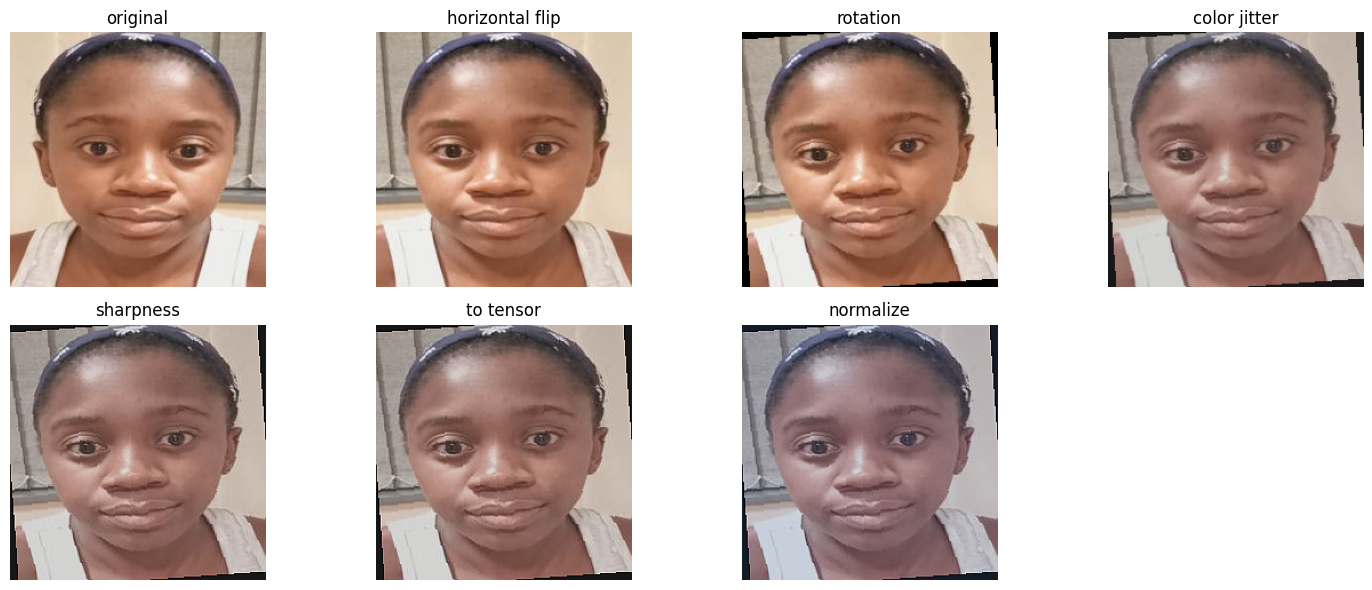

In [9]:
# cek 1 foto
# tiap runningnya beda (random)

img = Image.open("../data/cropped/realperson/real_002.jpg").convert("RGB")

# definisikan step dengan format konsisten
steps = [
    ("original", None),
    ("horizontal flip", transforms.RandomHorizontalFlip(p=0.5)),
    ("rotation", transforms.RandomRotation(10)),

    ("color jitter", transforms.ColorJitter(
        brightness=0.3,
        contrast=0.2,
        saturation=0.3,
        hue=0.05
    )),

    ("sharpness", transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3)),

    ("to tensor", transforms.ToTensor()),

    ("normalize", transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ))
]

def tensor_to_img(t):
    t = t.clone().detach()
    if t.shape[0] == 3:
        t = t.permute(1, 2, 0)
    t = t.numpy()
    t = (t - t.min()) / (t.max() - t.min() + 1e-5)
    return t

current = img
results = []

for name, transform in steps:
    if transform is not None:
        current = transform(current)
    results.append((name, current))

plt.figure(figsize=(15, 6))

for i, (name, im) in enumerate(results):
    plt.subplot(2, 4, i+1)

    if isinstance(im, Image.Image):
        plt.imshow(im)
    else:
        plt.imshow(tensor_to_img(im))

    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# dataset tanpa transform
full_dataset = datasets.ImageFolder(
    root=TRAIN_PATH
)
class_names = full_dataset.classes

In [11]:
# split index
targets = full_dataset.targets  # label tiap data

train_indices, val_indices = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.1,
    stratify=targets,
    random_state=42
)

In [15]:
# buat dataset terpisah
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform),
    train_indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=TRAIN_PATH, transform=val_transform),
    val_indices
)

## <b>tuning

In [16]:
print(f"Data --> Train: {len(train_dataset)}, Val: {len(val_dataset)}")

def objective(trial):

    # hyperparameter space
    batch_size = trial.suggest_categorical("batch_size", [4, 8, 16])
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "SGD"])
    drop_rate = trial.suggest_float("drop_rate", 0.0, 0.5)

    # data loader (dinamis)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # model
    model = timm.create_model(
        'efficientnet_b3',
        pretrained=True,
        num_classes=len(classes),
        drop_rate=drop_rate
    ).to(device)

    # loss
    criterion = nn.CrossEntropyLoss()

    # optimizer
    if optimizer_name == "AdamW":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    else:
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    # training
    EPOCHS_TUNE = 5
    best_val_acc = 0.0

    for epoch in range(EPOCHS_TUNE):

        # train
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total

        # best score
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        # pruning
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_acc

Data --> Train: 1323, Val: 148


In [17]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

[I 2026-04-09 22:29:46,119] A new study created in memory with name: no-name-9d729139-e6d2-4fb4-9802-1354c8f75532
[I 2026-04-09 22:33:02,130] Trial 0 finished with value: 0.2972972972972973 and parameters: {'batch_size': 8, 'lr': 1.0717595479254277e-05, 'weight_decay': 8.46742068252318e-06, 'optimizer': 'SGD', 'drop_rate': 0.1533475048134303}. Best is trial 0 with value: 0.2972972972972973.
[I 2026-04-09 22:44:09,994] Trial 1 finished with value: 0.6756756756756757 and parameters: {'batch_size': 4, 'lr': 0.0001567848207888087, 'weight_decay': 0.00027000725577227576, 'optimizer': 'SGD', 'drop_rate': 0.012930594703971399}. Best is trial 1 with value: 0.6756756756756757.
[I 2026-04-09 22:50:34,641] Trial 2 finished with value: 0.6621621621621622 and parameters: {'batch_size': 8, 'lr': 2.935213637833695e-05, 'weight_decay': 6.401867484216626e-05, 'optimizer': 'AdamW', 'drop_rate': 0.3153390006934677}. Best is trial 1 with value: 0.6756756756756757.
[I 2026-04-09 22:53:33,424] Trial 3 finis

In [23]:
best_params = study.best_trial.params
print("Best Trial:")
print(study.best_trial.params)

Best Trial:
{'batch_size': 4, 'lr': 0.0004540786831865708, 'weight_decay': 1.0620192684231041e-06, 'optimizer': 'AdamW', 'drop_rate': 0.4848982563007385}


## <b>MODEL 1 (Efficient Net b3)

1. Set seed
2. Model
3. Loss
4. Optimizer
5. Scheduler
6. AMP
7. Train setup
8. Validation
9. Save best model<br><br>
10. Load best model
11. Predict test

In [27]:
best_params = study.best_trial.params

BATCH_SIZE = best_params['batch_size']
LEARNING_RATE = best_params['lr']
WEIGHT_DECAY = best_params['weight_decay']
OPTIMIZER_NAME = best_params['optimizer']
DROP_RATE = best_params['drop_rate']
EPOCHS = 25
patience = 3

In [25]:
# data loader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

> Train 90 10

In [26]:
# 1. set seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [28]:
# 2. model
model = timm.create_model(
    'efficientnet_b3',
    pretrained=True,
    num_classes=len(classes),
    drop_rate=DROP_RATE
)
model = model.to(device)

# 3. loss
criterion = nn.CrossEntropyLoss()

# 4. optimizer
if OPTIMIZER_NAME == "AdamW":
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
elif OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=0.9,
        weight_decay=WEIGHT_DECAY
    )
else:
    raise ValueError("Optimizer tidak dikenali")

# 5. scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# 6. amp
scaler = torch.amp.GradScaler('cuda')

In [29]:
# 7. train setup
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0

patience = 3
patience_counter = 0

model_dir = '../models/'
os.makedirs(model_dir, exist_ok=True)
model_save_path = os.path.join(model_dir, 'efficientnet_b3_model.pth')

# 8. training + validation
print("Training...")

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        current_lr = scheduler.get_last_lr()[0]
        train_pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'lr': f"{current_lr:.6f}"
        })

    scheduler.step()

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # 9. save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"Model terbaik disimpan! Acc: {best_val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

print(f"\nTraining selesai. Best Acc: {best_val_acc:.4f}")

Training...


Epoch 1/25 [Val]: 100%|██████████| 37/37 [00:02<00:00, 14.77it/s]


Epoch 1 | Train Loss: 1.6981 | Val Loss: 1.1732 | Val Acc: 0.6351
Model terbaik disimpan! Acc: 0.6351


Epoch 2/25 [Val]: 100%|██████████| 37/37 [00:02<00:00, 14.94it/s]


Epoch 2 | Train Loss: 0.9923 | Val Loss: 0.7005 | Val Acc: 0.7568
Model terbaik disimpan! Acc: 0.7568


...

Epoch 7 | Train Loss: 0.2690 | Val Loss: 0.5681 | Val Acc: 0.8649
No improvement: 1/3


Epoch 8/25 [Val]: 100%|██████████| 37/37 [00:02<00:00, 13.82it/s]


Epoch 8 | Train Loss: 0.3333 | Val Loss: 0.5561 | Val Acc: 0.8176
No improvement: 2/3


Epoch 9/25 [Val]: 100%|██████████| 37/37 [00:02<00:00, 14.56it/s]

Epoch 9 | Train Loss: 0.3446 | Val Loss: 0.4515 | Val Acc: 0.8851
No improvement: 3/3
Early stopping triggered

Training selesai. Best Acc: 0.8851


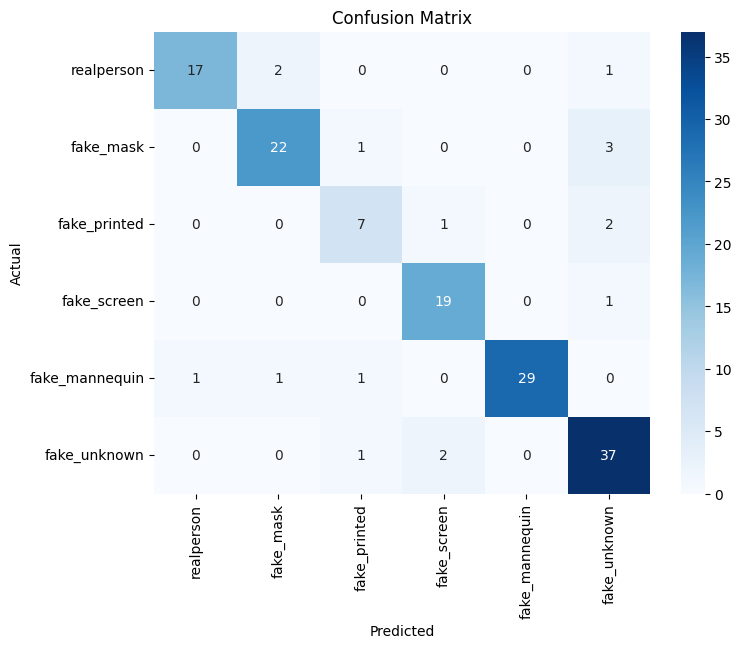


===== METRICS =====
Accuracy  : 0.8851
Precision : 0.8715
Recall    : 0.8629
F1 Score  : 0.8657

===== CLASSIFICATION REPORT =====
                precision    recall  f1-score   support

    realperson       0.94      0.85      0.89        20
     fake_mask       0.88      0.85      0.86        26
  fake_printed       0.70      0.70      0.70        10
   fake_screen       0.86      0.95      0.90        20
fake_mannequin       1.00      0.91      0.95        32
  fake_unknown       0.84      0.93      0.88        40

      accuracy                           0.89       148
     macro avg       0.87      0.86      0.87       148
  weighted avg       0.89      0.89      0.89       148



In [30]:
# metrik evaluasi

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# basic metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n===== METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# detail per class
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(all_labels, all_preds, target_names=classes))

> evaluasi train 90

In [ ]:
# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load(model_save_path))
model.eval()

# =========================
# PREDICT TRAIN SET (90%)
# =========================
all_preds_train = []
all_labels_train = []

with torch.no_grad():
    train_eval_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,   # penting biar urutan konsisten
        num_workers=0,
        pin_memory=True
    )

    for inputs, labels in tqdm(train_eval_loader, desc="Evaluating Train Set"):
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

Evaluating Train Set: 100%|██████████| 331/331 [00:18<00:00, 18.26it/s]


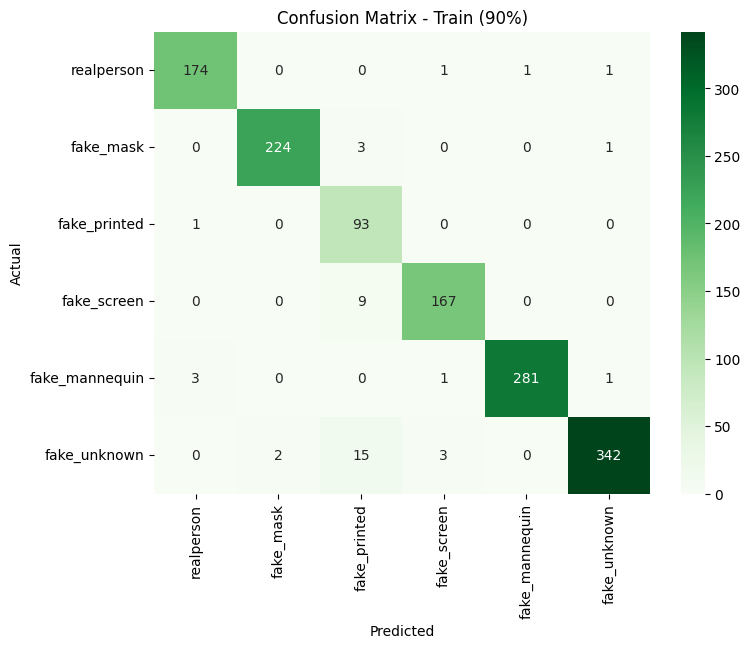

In [43]:
cm_train = confusion_matrix(all_labels_train, all_preds_train)

plt.figure(figsize=(8,6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Train (90%)")
plt.show()

In [33]:
acc_train = accuracy_score(all_labels_train, all_preds_train)
precision_train = precision_score(all_labels_train, all_preds_train, average='macro')
recall_train = recall_score(all_labels_train, all_preds_train, average='macro')
f1_train = f1_score(all_labels_train, all_preds_train, average='macro')

print("\n===== TRAIN METRICS (80%) =====")
print(f"Accuracy  : {acc_train:.4f}")
print(f"Precision : {precision_train:.4f}")
print(f"Recall    : {recall_train:.4f}")
print(f"F1 Score  : {f1_train:.4f}")


===== TRAIN METRICS (80%) =====
Accuracy  : 0.9683
Precision : 0.9504
Recall    : 0.9718
F1 Score  : 0.9588


In [34]:
print("\n===== CLASSIFICATION REPORT (TRAIN 80%) =====")
print(classification_report(all_labels_train, all_preds_train, target_names=classes))


===== CLASSIFICATION REPORT (TRAIN 80%) =====
                precision    recall  f1-score   support

    realperson       0.98      0.98      0.98       177
     fake_mask       0.99      0.98      0.99       228
  fake_printed       0.78      0.99      0.87        94
   fake_screen       0.97      0.95      0.96       176
fake_mannequin       1.00      0.98      0.99       286
  fake_unknown       0.99      0.94      0.97       362

      accuracy                           0.97      1323
     macro avg       0.95      0.97      0.96      1323
  weighted avg       0.97      0.97      0.97      1323



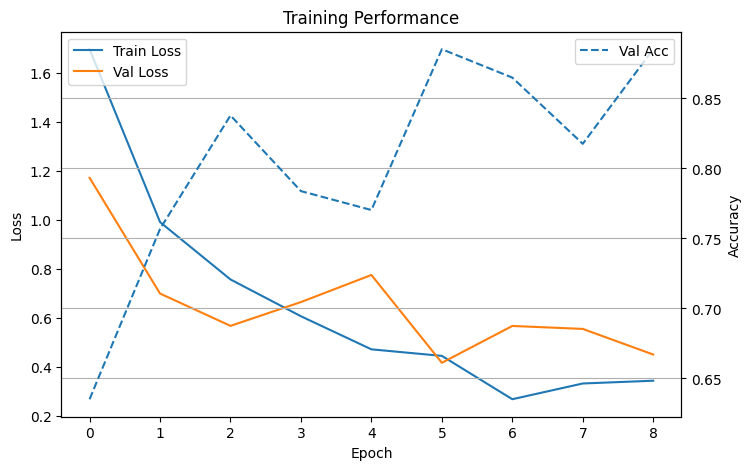

In [35]:
# training performance

fig, ax1 = plt.subplots(figsize=(8,5))

# Loss
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left')

# Accuracy (secondary axis)
ax2 = ax1.twinx()
ax2.plot(val_accuracies, linestyle='--', label='Val Acc')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='upper right')

plt.title('Training Performance')
plt.grid(True)
plt.show()

> Train 100

### <b>predict

In [36]:
# load model
model_path = '../models/efficientnet_b3_model.pth'

best_model = timm.create_model(
    'efficientnet_b3',
    pretrained=False,
    num_classes=len(classes),
    drop_rate=0.3
)

best_model.load_state_dict(torch.load(model_path, map_location=device))
best_model = best_model.to(device)
best_model.eval()

print("Best model loaded dari:", model_path)

Best model loaded dari: ../models/efficientnet_b3_model.pth


In [42]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted(os.listdir(root_dir))  # penting biar urut

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name
    
TEST_PATH = '../data/cropped_test'

test_dataset = TestDataset(TEST_PATH, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test data: {len(test_dataset)}")

Test data: 404


In [41]:
results = []

with torch.no_grad():
    for inputs, img_names in tqdm(test_loader, desc="Predicting"):
        inputs = inputs.to(device)

        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)

        for name, pred in zip(img_names, preds):
            label = classes[pred.item()]
            results.append((name, label))

Predicting:   0%|          | 0/101 [00:00<?, ?it/s]


RuntimeError: stack expects each tensor to be equal size, but got [3, 1920, 1080] at entry 0 and [3, 1390, 946] at entry 1

### <b>submit

In [39]:
df = pd.DataFrame(results, columns=["id", "label"])

# hilangin .jpg kalau perlu
df["id"] = df["id"].str.replace(r"\.(jpg|jpeg|png)$", "", regex=True)

# urutin (biar test_001, test_002, ...)
df = df.sort_values("id")

df.to_csv("submission.csv", index=False)

print("Submission berhasil dibuat!")

Submission berhasil dibuat!


In [ ]:
# tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_5 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_5.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_5.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_5.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_5.add(BatchNormalization())
model_5.add(MaxPooling2D((2, 2)))

# Flatten layer
model_5.add(Flatten())
# 1nd Dense Layer
model_5.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_5.add(Dropout(0.5))
# 2nd Dense Layer
model_5.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_5.add(Dropout(0.3))
# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_5.add(Dense(1, activation='sigmoid'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_5.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_5.summary())

In [ ]:
count_normal, count_pneumonia = len(os.listdir(train_normal)), len(os.listdir(train_pneumonia))
weight_0 = (1 / count_normal) * (count_normal + count_pneumonia) / 2.0
weight_1 = (1 / count_pneumonia) * (count_pneumonia + count_normal) / 2.0

class_weights = {0 : weight_0, 1 : weight_1}


%time

# Fitting / training model
history_5 = model_5.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=validation_generator,
                        class_weight = class_weights)

In [ ]:
acc = history_5.history['accuracy']
val_acc = history_5.history['val_accuracy']
loss = history_5.history['loss']
val_loss = history_5.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [ ]:
test_generator.reset()

preds_5 = model_5.predict(test_generator,verbose=0)
preds_5 = preds_5.copy()
preds_5[preds_5 <= 0.5] = 0
preds_5[preds_5 > 0.5] = 1

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_5, labels=[0, 1]),index=["Actual Normal", "Actual Pneumonia"],
columns=["Predicted Normal", "Predicted Pneumonia"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_5,target_names =['Normal','Pneumonia'], digits=4))